In [1]:
# Using the Best model for Tomato on plant village which has all 15 classses of the three plants combined

import tensorflow as tf 
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt

EPOCHS = 30
BATCH_SIZE = 32
INPUT_SHAPE = (256, 256, 3)


# Load datasets
def load_dataset(directory):
    return tf.keras.preprocessing.image_dataset_from_directory(
        directory,
        batch_size=BATCH_SIZE,
        image_size=(256, 256),
        shuffle=True
    )

train_ds = load_dataset("/mnt/home/alwanai/virtualenv/plantVillage/train")
test_ds = load_dataset("/mnt/home/alwanai/virtualenv/plantVillage/test")
val_ds = load_dataset("/mnt/home/alwanai/virtualenv/plantVillage/val")

input_shape = (256, 256, 3)  
n_classes = 15  

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)


resize_and_rescale = tf.keras.Sequential([
    tf.keras.layers.Resizing(256, 256),
    tf.keras.layers.Rescaling(1.0 / 255)
])

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2)
])

model = models.Sequential([
    tf.keras.layers.InputLayer(shape=input_shape),
    resize_and_rescale,
    data_augmentation,
    tf.keras.layers.Conv2D(32, kernel_size=(3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Conv2D(64, kernel_size=(3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Conv2D(64, kernel_size=(3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Conv2D(64, kernel_size=(3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Conv2D(64, kernel_size=(3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Conv2D(64, kernel_size=(3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(n_classes, activation='softmax')  
])

model.build(input_shape=(None, 256, 256, 3))
model.summary()

model.compile(
    optimizer = 'adam',
    loss= tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

history = model.fit(
    train_ds,
    epochs = 50,
    batch_size=32,
    verbose= 1,
    validation_data = val_ds
)

2025-03-26 13:03:52.480319: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-26 13:03:52.502433: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1743008632.524454 3145974 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1743008632.531500 3145974 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-26 13:03:52.560165: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

Found 14440 files belonging to 15 classes.


2025-03-26 13:03:58.020086: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Found 3109 files belonging to 15 classes.
Found 3089 files belonging to 15 classes.


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │           975 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 184,527 (720.81 KB)

 Trainable params: 184,527 (720.81 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
452/452 ━━━━━━━━━━━━━━━━━━━━ 89s 186ms/step - accuracy: 0.2218 - loss: 2.3536 - val_accuracy: 0.4639 - val_loss: 1.6213
Epoch 2/50
452/452 ━━━━━━━━━━━━━━━━━━━━ 70s 154ms/step - accuracy: 0.5099 - loss: 1.4735 - val_accuracy: 0.5892 - val_loss: 1.3004
Epoch 3/50
452/452 ━━━━━━━━━━━━━━━━━━━━ 80s 177ms/step - accuracy: 0.6875 - loss: 0.8905 - val_accuracy: 0.6934 - val_loss: 0.9599
Epoch 4/50
452/452 ━━━━━━━━━━━━━━━━━━━━ 79s 175ms/step - accuracy: 0.7525 - loss: 0.7196 - val_accuracy: 0.7753 - val_loss: 0.6867
Epoch 5/50
452/452 ━━━━━━━━━━━━━━━━━━━━ 78s 172ms/step - accuracy: 0.8024 - loss: 0.5762 - val_accuracy: 0.7329 - val_loss: 0.8397
Epoch 6/50
452/452 ━━━━━━━━━━━━━━━━━━━━ 82s 172ms/step - accuracy: 0.8232 - loss: 0.5168 - val_accuracy: 0.7860 - val_loss: 0.6813
Epoch 7/50
452/452 ━━━━━━━━━━━━━━━━━━━━ 77s 170ms/step - accuracy: 0.8452 - loss: 0.4415 - val_accuracy: 0.8223 - val_loss: 0.5303
Epoch 8/50
452/452 ━━━━━━━━━━━━━━━━━━━━ 76s 169ms/step - accuracy: 0.8639 - loss: 0

In [2]:
test_loss, test_accuracy = model.evaluate(test_ds)
print(f"Test Loss: {test_loss}, Test Accuracy: {test_accuracy}")

98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.9382 - loss: 0.2304
Test Loss: 0.24115188419818878, Test Accuracy: 0.9366355538368225


In [3]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

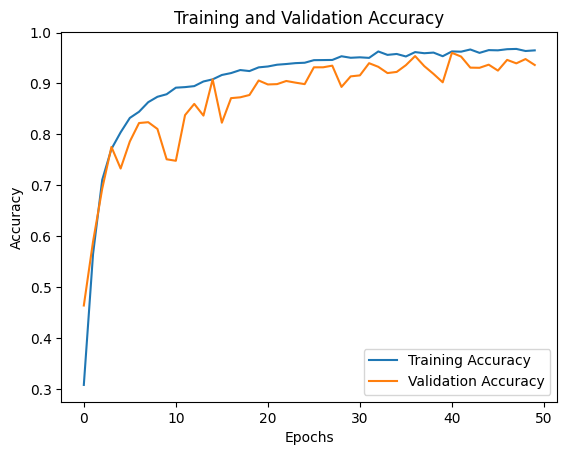

In [4]:
plt.plot(range(len(acc)), acc, label='Training Accuracy')
plt.plot(range(len(val_acc)), val_acc, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()